📂 [데이터 로드] Baseline, 기존 VCD, 제안 기법(B-VCD) 점수 동시 파싱 중...

  - Blur 10, Noise 7.5 ➡️ B-VCD 평균 점수: 3.19, 승률: 66.7%
  - Blur 30, Noise 7.5 ➡️ B-VCD 평균 점수: 3.24, 승률: 74.7%
  - Blur 20, Noise 7.5 ➡️ B-VCD 평균 점수: 3.28, 승률: 72.8%
  - Blur 20, Noise 2.5 ➡️ B-VCD 평균 점수: 3.12, 승률: 67.8%
  - Blur 30, Noise 2.5 ➡️ B-VCD 평균 점수: 3.33, 승률: 69.5%
  - Blur 10, Noise 5.0 ➡️ B-VCD 평균 점수: 3.11, 승률: 62.9%
  - Blur 30, Noise 5.0 ➡️ B-VCD 평균 점수: 3.18, 승률: 68.4%
  - Blur 10, Noise 2.5 ➡️ B-VCD 평균 점수: 3.12, 승률: 73.4%
  - Blur 20, Noise 5.0 ➡️ B-VCD 평균 점수: 2.78, 승률: 58.7%


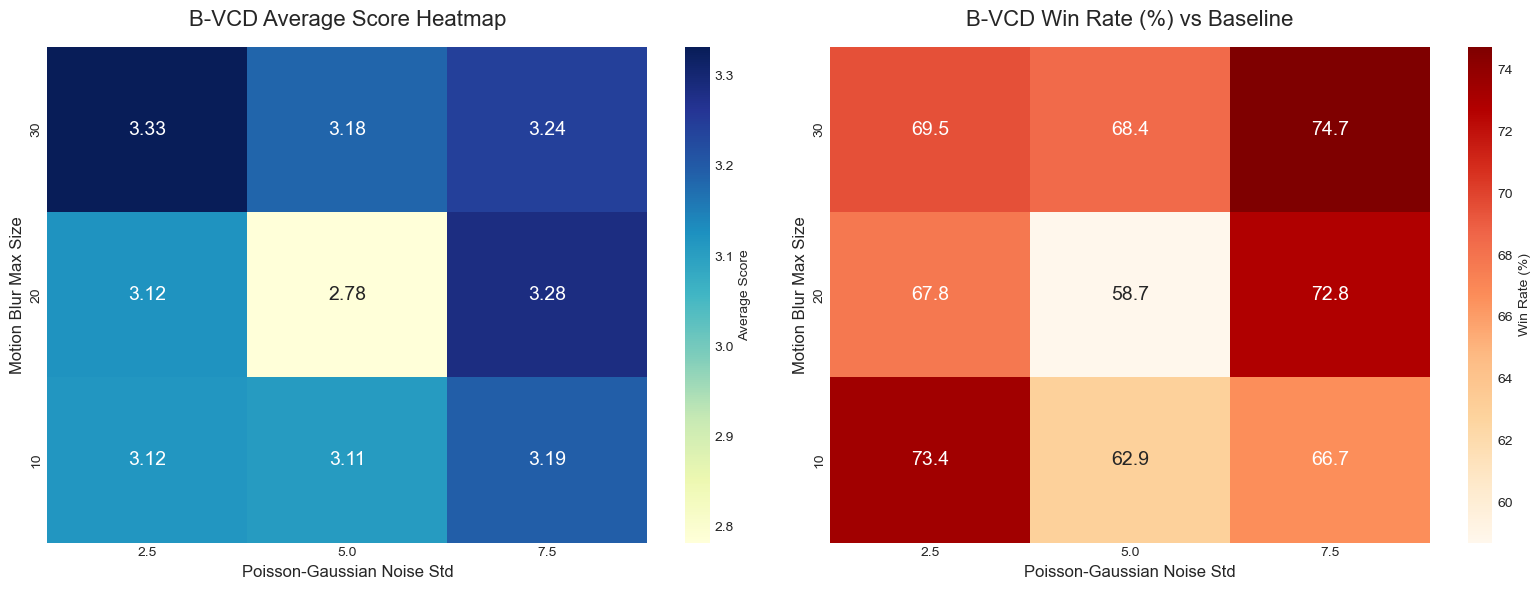


🏆 [최종 결론] B-VCD 황금 조합 vs 기존 모델들 성능 완벽 비교
📌 발견된 최적 파라미터 : 모션 블러 30, 포아송 노이즈 2.5

[1. 평균 점수 비교 (5점 만점)]
  ⚪ Baseline (순수 LLaVA)     : 1.94점
  🟡 기존 VCD (가우시안 노이즈) : 3.05점
  🔴 제안 B-VCD (황금 조합)     : 3.33점

[2. 점수 향상폭 (Score Improvement)]
  ➡️ B-VCD는 Baseline 대비 평균 점수 +1.39점 상승!
  ➡️ B-VCD는 기존 VCD 대비 평균 점수 +0.28점 상승!

[3. Baseline 대비 승률 (Win Rate)]
  - 기존 VCD가 원본을 이길 확률  : 65.4%
  - 제안 B-VCD가 원본을 이길 확률 : 69.5%
  ➡️ B-VCD가 기존 방식보다 승률을 +4.1%p 끌어올렸습니다!


In [4]:
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 9개의 튜닝 결과 파일 로드 및 3가지 모델 동시 파싱
# ==========================================
RESULTS_DIR = "../Results/"
file_pattern = re.compile(r"tuning_eval_blur(\d+)_noise(\d+_\d+).json")

grid_results = []

print(" [데이터 로드] Baseline, 기존 VCD, 제안 기법(B-VCD) 점수 동시 파싱 중...\n")
for filename in os.listdir(RESULTS_DIR):
    match = file_pattern.search(filename)
    if not match:
        continue
        
    blur_val = int(match.group(1))
    noise_val = float(match.group(2).replace('_', '.'))
    
    filepath = os.path.join(RESULTS_DIR, filename)
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    cand1_scores = [] # Baseline (순수 LLaVA)
    cand2_scores = [] # VCD (기존 기술)
    cand3_scores = [] # B-VCD (제안 기술)
    
    cand2_win_count = 0 # VCD가 Baseline을 이긴 횟수
    cand3_win_count = 0 # B-VCD가 Baseline을 이긴 횟수
    valid_evals = 0
    
    for item in data:
        eval_log = item.get("evaluation_log", "")
        # Candidate 1, 2, 3의 점수를 모두 추출
        scores = re.findall(r"Candidate\s*\d+\s*:\s*([0-5](?:\.\d+)?)", eval_log)
        
        if len(scores) >= 3:
            try:
                s1 = float(scores[0]) # Baseline
                s2 = float(scores[1]) # Original VCD (Candidate 2)
                s3 = float(scores[2]) # Our B-VCD (Candidate 3)
                
                cand1_scores.append(s1)
                cand2_scores.append(s2)
                cand3_scores.append(s3)
                
                if s2 > s1: cand2_win_count += 1
                if s3 > s1: cand3_win_count += 1
                
                valid_evals += 1
            except ValueError:
                continue

    if valid_evals > 0:
        avg_1 = sum(cand1_scores) / valid_evals
        avg_2 = sum(cand2_scores) / valid_evals
        avg_3 = sum(cand3_scores) / valid_evals
        
        win_2 = (cand2_win_count / valid_evals) * 100
        win_3 = (cand3_win_count / valid_evals) * 100
        
        grid_results.append({
            "Blur": blur_val,
            "Noise": noise_val,
            "Base_Avg": avg_1,
            "VCD_Avg": avg_2,
            "VCD_WinRate": win_2,
            "BVCD_Avg": avg_3,
            "BVCD_WinRate": win_3
        })
        print(f"  - Blur {blur_val}, Noise {noise_val}  B-VCD 평균 점수: {avg_3:.2f}, 승률: {win_3:.1f}%")

# ==========================================
# 2. 히트맵 시각화 (이미지 출력)
# ==========================================
df = pd.DataFrame(grid_results)

# 히트맵을 그리기 위해 x축(Noise), y축(Blur) 형태로 피벗(Pivot) 테이블 생성
score_pivot = df.pivot(index="Blur", columns="Noise", values="BVCD_Avg")
winrate_pivot = df.pivot(index="Blur", columns="Noise", values="BVCD_WinRate")

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] B-VCD 평균 점수 히트맵
sns.heatmap(score_pivot, annot=True, fmt=".2f", cmap="YlGnBu", 
            cbar_kws={'label': 'Average Score'}, ax=axes[0], annot_kws={"size": 14})
axes[0].set_title("B-VCD Average Score Heatmap", fontsize=16, pad=15)
axes[0].set_xlabel("Poisson-Gaussian Noise Std", fontsize=12)
axes[0].set_ylabel("Motion Blur Max Size", fontsize=12)
axes[0].invert_yaxis() # y축(Blur)이 위로 갈수록 커지게 설정

# [그래프 2] B-VCD 승률 히트맵 (vs Baseline)
sns.heatmap(winrate_pivot, annot=True, fmt=".1f", cmap="OrRd", 
            cbar_kws={'label': 'Win Rate (%)'}, ax=axes[1], annot_kws={"size": 14})
axes[1].set_title("B-VCD Win Rate (%) vs Baseline", fontsize=16, pad=15)
axes[1].set_xlabel("Poisson-Gaussian Noise Std", fontsize=12)
axes[1].set_ylabel("Motion Blur Max Size", fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../Results/grid_search_heatmap_final.png", dpi=300)
plt.show()

# ==========================================
# 3. 결과 분석 및 3단 비교 텍스트 출력
# ==========================================
# B-VCD 점수가 가장 높은 최적의 행(Global Optimum) 찾기
best_row = df.loc[df['BVCD_Avg'].idxmax()]

# Baseline과 VCD는 파라미터와 무관하게 고정값이므로 전체 평균으로 추출
base_final_avg = df['Base_Avg'].mean()
vcd_final_avg = df['VCD_Avg'].mean()
vcd_final_winrate = df['VCD_WinRate'].mean()

print("\n" + "="*65)
print(f" [최종 결론] B-VCD 최적 조합 vs 기존 모델들 성능 비교")
print("="*65)
print(f" 발견된 최적 파라미터 : 모션 블러 {int(best_row['Blur'])}, 포아송 노이즈 {best_row['Noise']}\n")

print(f"[1. 평균 점수 비교 (5점 만점)]")
print(f"   Baseline (순수 LLaVA)     : {base_final_avg:.2f}점")
print(f"   기존 VCD (가우시안 노이즈) : {vcd_final_avg:.2f}점")
print(f"   제안 B-VCD (최적 조합)     : {best_row['BVCD_Avg']:.2f}점\n")

print(f"[2. 점수 향상폭 (Score Improvement)]")
score_diff_base = best_row['BVCD_Avg'] - base_final_avg
score_diff_vcd = best_row['BVCD_Avg'] - vcd_final_avg
print(f"   B-VCD는 Baseline 대비 평균 점수 +{score_diff_base:.2f}점 상승.")
print(f"   B-VCD는 기존 VCD 대비 평균 점수 +{score_diff_vcd:.2f}점 상승.\n")

print(f"[3. Baseline 대비 승률 (Win Rate)]")
print(f"  - 기존 VCD가 원본을 이길 확률  : {vcd_final_winrate:.1f}%")
print(f"  - 제안 B-VCD가 원본을 이길 확률 : {best_row['BVCD_WinRate']:.1f}%")
winrate_diff = best_row['BVCD_WinRate'] - vcd_final_winrate
print(f"   B-VCD가 기존 방식보다 승률을 +{winrate_diff:.1f}%p 끌어올렸습니다.")
print("="*65)